# MIE1517 Course Project Report Draft
## Automated Skin Cancer Detection via Hybrid DenseNet-EfficientNet CNN

**Team 1 -- University of Toronto, MIE1517**

- Haowen Chang (1006205394)
- Purui Yi (1005789737)
- Yushu Ding (1005841840)

- **GitHub Repo:** https://github.com/HaowenCh/MIE1517-Skin-Cancer-Classification.git
---

## Table of Contents

1. [Project Description](#1-project-description)
2. [Setup -- Imports & Configuration](#2-setup)
3. [Data Loading & Exploratory Analysis](#3-data-loading)
4. [Dataset Class](#4-dataset-class)
5. [Train / Validation / Test Split & Class Imbalance Handling](#5-split)
6. [Model Architecture -- Hybrid DenseNet-121 + EfficientNet-B4](#6-model)
7. [Training Strategy](#7-training-strategy)
8. [Training](#8-training)
9. [Training Curves](#9-curves)
10. [Decision Threshold Calibration](#10-threshold)
11. [Evaluation on Test Set](#11-evaluation)
12. [RNN Baseline -- Spatial Patch-Sequence BiLSTM](#12-rnn)
13. [Model Comparison](#13-comparison)
14. [RNN Baseline -- Test Set Image Predictions](#14-rnn-predictions)
15. [Personal Skin Lesion Prediction](#15-personal)
16. [Summary and Discussion](#16-summary)

## 1. Project Description

### Background & Motivation

Skin cancer is one of the most prevalent cancers globally, with melanoma accounting for the majority of skin cancer-related deaths. Clinical diagnosis relies on dermoscopy and expert visual inspection, achieving typical accuracy of 70-80%. Early detection is critical: 5-year survival rates drop from >98% (localized) to ~30% (metastatic) for melanoma. An automated, reliable detection system could serve as a scalable first-line screening tool, flagging high-risk lesions for expedited expert review.

### Dataset

This project uses the **ISIC 2024 SLICE-3D** dataset, which consists of 3D Total Body Photography (TBP) cropped lesion images captured under standardized conditions. The task is **binary classification**: predicting whether a lesion is malignant (1) or benign (0).

- Training source: SLICE-3D Dataset (~401,059 samples)
- External test reference: HAM10000 Dataset (~10,015 samples)
- Severe class imbalance: approximately 99% benign, 1% malignant

### Approach

We develop a **hybrid deep learning architecture** that combines two complementary pretrained CNNs in parallel:

- **DenseNet-121** -- dense skip connections promote fine-grained texture feature reuse across layers, capturing detailed local patterns such as pigmentation irregularities and surface texture
- **EfficientNet-B4** -- compound scaling of depth, width, and resolution enables efficient multi-scale pattern recognition, capturing global lesion shape and colour gradients

Both branches process the same lesion image independently. Their feature vectors (1024-d and 1792-d) are concatenated into a 2816-d fused representation and passed through a fusion MLP classifier for binary prediction. This parallel design avoids the information bottleneck that would arise from sequential combination and lets each branch specialize freely during training.

### Key Design Decisions

- **Focal Loss** replaces standard BCE to handle the severe (~98:2) class imbalance by down-weighting easy benign examples and focusing gradient on hard malignant cases
- **WeightedRandomSampler** ensures every training batch is approximately class-balanced
- **Decision threshold calibration** on the validation set replaces the default 0.5, optimising sensitivity/specificity for a medical screening context
- **AUPRC** (Area under Precision-Recall Curve) is the primary evaluation metric, more sensitive to minority-class performance under severe imbalance than AUC-ROC

## 2. Setup -- Imports & Configuration

All third-party dependencies are imported here and a single configuration block at the top
of the notebook controls every tuneable parameter. Fixing all random seeds
(`torch`, `numpy`, `random`) before any model initialisation ensures that results are
reproducible across runs on the same hardware.

Key configuration values used throughout the notebook:

- `IMAGE_SIZE = 224` -- input resolution expected by both DenseNet-121 and EfficientNet-B4
- `BATCH_SIZE = 32` -- largest batch that fits in GPU memory for B4; increase if using
  a smaller backbone
- `NUM_WORKERS = 0` -- required on Windows in a Jupyter environment to avoid the
  multiprocessing spawn deadlock; safe to increase on Linux/macOS
- `NUM_EPOCHS = 20` -- upper bound; early stopping typically terminates earlier
- `LR = 1e-4` -- starting learning rate for AdamW; decayed to `1e-6` via cosine annealing
- `DROPOUT = 0.4` -- applied at the fusion head; halved for the second dropout layer
- `DEVICE` -- automatically selects CUDA if available, otherwise CPU

In [ ]:
import os, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

In [10]:
# Paths
ROOT      = Path('.')
IMAGE_DIR = ROOT / 'ISIC_2024_Training_Input'
GT_CSV    = ROOT / 'ISIC_2024_Training_GroundTruth.csv'

# Data split
TRAIN_RATIO = 0.60      # 60 / 20 / 20

# Image
IMAGE_SIZE  = 224

# Training
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4

# Focal Loss
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# Checkpoint -- named uniquely to avoid conflicts with other notebooks
CKPT_PATH   = 'best_hybrid_model.pth'

# Keep NUM_WORKERS=0 on Windows inside Jupyter to avoid spawn deadlock
NUM_WORKERS = 0

# Set to <1.0 for fast iteration (e.g. 0.1 uses 10% of data)
SAMPLE_FRACTION = 1.0

## 3. Data Loading & Exploratory Analysis

The ground truth CSV (`ISIC_2024_Training_GroundTruth.csv`) contains two columns: `isic_id` (the image filename stem) and `malignant` (0 = benign, 1 = malignant). Images are matched by filename and rows without a corresponding file are dropped before splitting.

Total samples : 401,059
Malignant     : 393  (0.10%)
Benign        : 400,666  (99.90%)


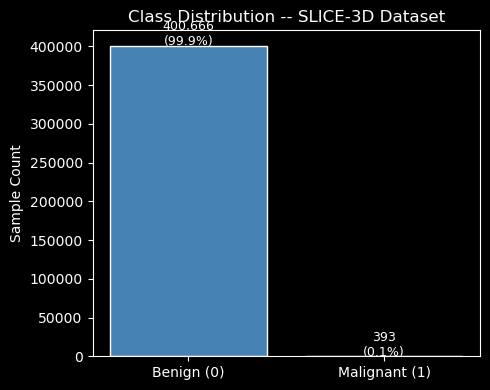

In [11]:
df = pd.read_csv(GT_CSV)
df['malignant'] = df['malignant'].astype(int)
df['img_path']  = df['isic_id'].apply(lambda x: IMAGE_DIR / f'{x}.jpg')
df = df[df['img_path'].apply(lambda p: p.exists())].reset_index(drop=True)

print(f'Total samples : {len(df):,}')
print(f"Malignant     : {df['malignant'].sum():,}  ({df['malignant'].mean()*100:.2f}%)")
print(f"Benign        : {(df['malignant']==0).sum():,}  ({(df['malignant']==0).mean()*100:.2f}%)")

if SAMPLE_FRACTION < 1.0:
    df = df.groupby('malignant', group_keys=False).apply(
        lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=SEED)
    ).reset_index(drop=True)
    print(f'\nAfter sampling ({SAMPLE_FRACTION:.0%}): {len(df):,}')

fig, ax = plt.subplots(figsize=(5, 4))
counts = df['malignant'].value_counts().sort_index()
ax.bar(['Benign (0)', 'Malignant (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution -- SLICE-3D Dataset')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 4. Dataset Class

A minimal PyTorch `Dataset` that opens images on demand and applies the configured transform. Keeping the dataset stateless (no caching) keeps memory usage manageable across 401k samples.

In [12]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        label = torch.tensor(row['malignant'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label

## 5. Train / Validation / Test Split & Class Imbalance Handling

### Stratified 60 / 20 / 20 Split

The dataset is split using stratified sampling to preserve the malignant class ratio in each partition. This ensures the 2% malignant prevalence is maintained consistently across train, validation, and test sets, making validation and test metrics directly comparable.

### Three-Layer Imbalance Strategy

The ~99:1 class imbalance is addressed at three complementary levels:

- **WeightedRandomSampler** (batch level) -- each training sample receives an inverse-class-frequency weight. The sampler draws approximately equal benign and malignant samples per batch, ensuring stable gradient signal for the minority class from the first epoch
- **Focal Loss** (sample level) -- within each batch, the loss further down-weights correctly and confidently classified samples (typically easy benign examples), concentrating the gradient on hard or misclassified examples. With gamma=2, a well-classified sample (p_t=0.9) contributes 100x less loss than a hard sample (p_t=0.1)
- **Threshold calibration** (inference level) -- after training, the decision boundary is shifted from 0.5 to the F1-optimal value on the validation set. This corrects for any residual probability miscalibration without retraining

### Data Augmentation

Training transforms apply the following augmentations to improve generalisation:

- Random crop (after upscaling by 32px) introduces spatial jitter and prevents the model from relying on fixed border context
- Horizontal and vertical flips exploit the rotational symmetry of skin lesions in TBP images
- Colour jitter (brightness, contrast, saturation, hue) handles variability in lighting conditions and skin tone across imaging sites
- Random rotation (up to 20 degrees) further regularizes spatial sensitivity

In [13]:
# Stratified 60 / 20 / 20 split
df_train, df_temp = train_test_split(
    df, test_size=(1-TRAIN_RATIO), stratify=df['malignant'], random_state=SEED)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp['malignant'], random_state=SEED)

print(f"Train : {len(df_train):>7,}  ({df_train['malignant'].mean()*100:.2f}% malignant)")
print(f"Val   : {len(df_val):>7,}  ({df_val['malignant'].mean()*100:.2f}% malignant)")
print(f"Test  : {len(df_test):>7,}  ({df_test['malignant'].mean()*100:.2f}% malignant)")

# Transforms
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

# Datasets
train_dataset = SkinLesionDataset(df_train, transform=train_transform)
val_dataset   = SkinLesionDataset(df_val,   transform=eval_transform)
test_dataset  = SkinLesionDataset(df_test,  transform=eval_transform)

# WeightedRandomSampler
n_benign    = (df_train['malignant'] == 0).sum()
n_malignant = (df_train['malignant'] == 1).sum()
cw = {0: 1.0/n_benign, 1: 1.0/n_malignant}
sample_weights = df_train['malignant'].map(cw).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nBatches -- Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Train : 240,635  (0.10% malignant)
Val   :  80,212  (0.10% malignant)
Test  :  80,212  (0.10% malignant)

Batches -- Train: 7520, Val: 2507, Test: 2507


## 6. Model Architecture -- Hybrid DenseNet-121 + EfficientNet-B4

### Design Rationale

No single CNN architecture captures all diagnostically relevant features equally well. DenseNet and EfficientNet have complementary strengths that make their parallel combination particularly suited to dermoscopy classification:

**DenseNet-121 branch:**
DenseNet introduces dense skip connections where every layer receives the concatenated feature maps of all preceding layers as input. This encourages maximal feature reuse and mitigates the vanishing-gradient problem. For skin lesion images, it excels at capturing fine-grained, high-resolution texture patterns -- subtle surface features such as atypical pigmentation networks, regression areas, and crystalline structures that are diagnostically significant for malignancy.

**EfficientNet-B4 branch:**
EfficientNet uses compound scaling to simultaneously increase network depth, width, and input resolution at a fixed ratio determined by a neural architecture search. Its multi-scale receptive fields at different stages span from individual dots and globules at fine scale to the overall lesion outline and colour gradient at coarse scale. This makes it effective at capturing global structural features of the lesion.

**Parallel fusion:**
Both branches process the same 224x224 image independently. The resulting feature vectors (1024-d from DenseNet, 1792-d from EfficientNet) are concatenated into a 2816-d representation before a fusion MLP classifier. Parallel combination avoids the information bottleneck of sequential fusion and lets each branch specialize freely during training.

**Architecture diagram**

```
Input Image (224 x 224 x 3)
       |                        |
       v                        v
DenseNet-121 features    EfficientNet-B4 features
(dense skip connections) (compound scaling)
       |  GlobalAvgPool          |  GlobalAvgPool
       v  1024-d                 v  1792-d
       +---------- concat -------+
                    |
                 2816-d
                    |
         BatchNorm -> Dropout(0.4)
                    |
            Linear(2816, 512)
                    |
                  ReLU
                    |
             Dropout(0.2)
                    |
              Linear(512, 1)
                    |
        logit -> sigmoid -> P(malignant)
           [binary: 0=Benign, 1=Malignant]
```

### Transfer Learning

Both backbones are initialized with ImageNet pretrained weights and fully fine-tuned end-to-end. ImageNet pretraining provides robust low and mid-level feature detectors (edges, textures, colour gradients) that transfer effectively to dermoscopy images, significantly reducing the labelled data required to reach strong performance compared to training from scratch.

In [14]:
class HybridDenseNetEfficientNet(nn.Module):
    # Hybrid CNN: DenseNet-121 (1024-d) + EfficientNet-B4 (1792-d) -> fused (2816-d)

    _DENSENET_OUT     = 1024
    _EFFICIENTNET_OUT = 1792

    def __init__(self, dropout: float = DROPOUT):
        super().__init__()

        # DenseNet-121: strip classifier head, keep convolutional feature extractor
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet_features = densenet.features
        self.densenet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # EfficientNet-B4: strip classifier head, keep convolutional feature extractor
        efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        self.efficientnet_features = efficientnet.features
        self.efficientnet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # Fusion classifier
        combined = self._DENSENET_OUT + self._EFFICIENTNET_OUT   # 2816
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(combined),
            nn.Dropout(dropout),
            nn.Linear(combined, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # DenseNet branch
        d = self.densenet_features(x)
        d = self.densenet_pool(d)
        d = torch.flatten(d, 1)           # (B, 1024)

        # EfficientNet branch
        e = self.efficientnet_features(x)
        e = self.efficientnet_pool(e)
        e = torch.flatten(e, 1)           # (B, 1792)

        fused = torch.cat([d, e], dim=1)  # (B, 2816)
        return self.classifier(fused).squeeze(1)  # (B,) logit


model = HybridDenseNetEfficientNet(dropout=DROPOUT).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

Total parameters    : 25,950,921
Trainable parameters: 25,950,921


## 7. Training Strategy

### Focal Loss

Standard Binary Cross-Entropy (BCE) assigns equal weight to every sample. With ~99% benign samples, easy negatives flood training with gradients that collectively suppress learning on the rare malignant cases.

Focal Loss (Lin et al., RetinaNet, 2017) modulates the per-sample loss with a focusing term:

```
FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
```

- `p_t` is the model probability assigned to the correct class
- `(1 - p_t)^gamma` approaches zero for confidently correct predictions, nearly zeroing out their gradient
- With `gamma=2`, a well-classified sample (p_t=0.9) is down-weighted 100x relative to a hard sample (p_t=0.1)
- `alpha=0.25` applies an additional prior weight on the positive (malignant) class

This concentrates the training budget on hard and misclassified examples -- precisely the ambiguous malignant lesions most critical to detect correctly.

### Optimizer -- AdamW

AdamW decouples L2 regularisation from the adaptive gradient scaling of Adam, providing cleaner weight decay behaviour. The `weight_decay=1e-4` term penalizes large weights without interfering with the per-parameter learning rate adaptation.

### Learning Rate Schedule -- Cosine Annealing

The learning rate is reduced smoothly from `1e-4` to `1e-6` following a cosine curve over all training epochs. This avoids abrupt drops (step decay) and allows fine-grained weight updates in later epochs when the model is near convergence.

### Mixed Precision (AMP)

On CUDA devices, `torch.cuda.amp` runs forward passes in float16 and keeps master weights in float32 via a `GradScaler`. This halves GPU memory usage and speeds training by ~1.5-2x with negligible accuracy loss.

### Early Stopping

Training halts if validation AUC-ROC does not improve for 5 consecutive epochs. The best checkpoint (highest val AUC) is saved and restored before evaluation.

In [ ]:
class FocalLoss(nn.Module):
    # Binary Focal Loss: FL(p_t) = -alpha*(1-p_t)^gamma*log(p_t)
    # Accepts raw logits; applies sigmoid internally via F.binary_cross_entropy_with_logits
    def __init__(self, alpha: float = FOCAL_ALPHA, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt    = torch.exp(-bce)
        focal = self.alpha * (1.0 - pt) ** self.gamma * bce
        return focal.mean()


criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

print(f'Loss      : FocalLoss(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})')
print(f'Optimizer : AdamW(lr={LR}, wd={WEIGHT_DECAY})')
print(f'Scheduler : CosineAnnealingLR(T_max={NUM_EPOCHS})')

## 8. Training

A shared `run_epoch` function handles both training and validation passes. In training mode
it applies the forward pass under `torch.cuda.amp.autocast`, scales the loss with a
`GradScaler`, back-propagates, and clips gradients to norm 1.0 before the optimizer step.
In evaluation mode (`optimizer=None`) gradients are disabled and raw logits are collected
for threshold calibration.

The outer training loop:

1. Runs `run_epoch` over the training loader (batches are class-balanced by
   `WeightedRandomSampler`)
2. Runs `run_epoch` over the validation loader to compute AUC-ROC
3. Saves a checkpoint whenever validation AUC improves (best-checkpoint strategy)
4. Steps the cosine-annealing scheduler after each epoch
5. Applies early stopping (patience = 5 epochs) to halt training once the model stops
   improving on the validation set

Per-epoch statistics (loss, AUC) are accumulated in `history` for later visualisation.

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None,
              device=DEVICE, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(images)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            running_loss = total_loss / ((batch_idx + 1) * images.size(0))
            pbar.set_postfix(loss=f'{running_loss:.4f}')

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    auprc    = average_precision_score(all_labels, all_probs)
    return avg_loss, auc, auprc


PATIENCE = 5
history  = {k: [] for k in
            ['train_loss','train_auc','train_auprc','val_loss','val_auc','val_auprc']}
best_val_auc = 0.0
patience_ctr = 0

epoch_pbar = tqdm(range(1, NUM_EPOCHS+1), desc='Epochs',
                  bar_format='{l_bar}{bar:20}{r_bar}')

for epoch in epoch_pbar:
    tr_loss, tr_auc, tr_auprc = run_epoch(
        model, train_loader, criterion, optimizer, scaler,
        desc=f'  Train [{epoch}/{NUM_EPOCHS}]')
    vl_loss, vl_auc, vl_auprc = run_epoch(
        model, val_loader, criterion,
        desc=f'  Val   [{epoch}/{NUM_EPOCHS}]')
    scheduler.step()

    for k, v in zip(history.keys(),
                    [tr_loss,tr_auc,tr_auprc,vl_loss,vl_auc,vl_auprc]):
        history[k].append(v)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        patience_ctr = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = ' *best*'
    else:
        patience_ctr += 1
        tag = f' (patience {patience_ctr}/{PATIENCE})'

    epoch_pbar.set_postfix(
        tr_auc=f'{tr_auc:.4f}', vl_auc=f'{vl_auc:.4f}',
        vl_auprc=f'{vl_auprc:.4f}')
    tqdm.write(
        f'Epoch {epoch:>3}/{NUM_EPOCHS} | '
        f'Train  loss={tr_loss:.4f}  AUC={tr_auc:.4f}  AUPRC={tr_auprc:.4f} | '
        f'Val    loss={vl_loss:.4f}  AUC={vl_auc:.4f}  AUPRC={vl_auprc:.4f}{tag}')

    if patience_ctr >= PATIENCE:
        tqdm.write(f'\nEarly stopping after epoch {epoch}.')
        break

tqdm.write(f'\nBest val AUC: {best_val_auc:.4f}  -- checkpoint: {CKPT_PATH}')

## 9. Training Curves

Three side-by-side panels give a quick diagnostic overview of the training run:

- **Loss** (left) -- Focal Loss on the training and validation splits. A closing gap between
  the two curves indicates good generalisation; a diverging gap signals overfitting.
- **AUC-ROC** (center) -- area under the ROC curve per epoch. Tracks overall
  discriminability regardless of threshold. The dashed vertical line marks the epoch at
  which the best checkpoint was saved.
- **AUPRC** (right) -- area under the Precision-Recall curve per epoch. More informative
  than AUC-ROC under severe class imbalance; a flat or declining AUPRC despite improving
  AUC indicates the model is becoming overconfident on easy negatives.

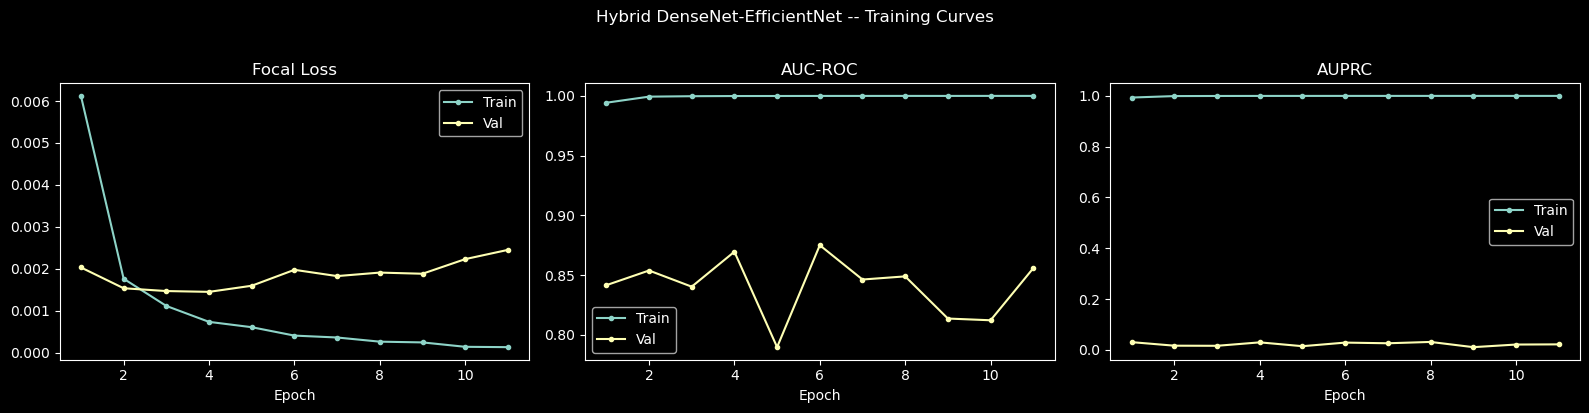

In [17]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (tr_k, vl_k), title in zip(
    axes,
    [('train_loss','val_loss'),('train_auc','val_auc'),('train_auprc','val_auprc')],
    ['Focal Loss', 'AUC-ROC', 'AUPRC']
):
    ax.plot(epochs_ran, history[tr_k], label='Train', marker='o', markersize=3)
    ax.plot(epochs_ran, history[vl_k], label='Val',   marker='o', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_title(title); ax.legend()

plt.suptitle('Hybrid DenseNet-EfficientNet -- Training Curves', y=1.02)
plt.tight_layout(); plt.show()

## 10. Decision Threshold Calibration

The default sigmoid threshold of 0.5 assumes balanced classes. With ~99% benign prevalence, this threshold produces very high specificity but poor sensitivity -- the model rarely predicts malignant, missing most true cases.

We sweep decision thresholds from 0.05 to 0.95 over the validation set and select the value that maximizes the **F1 score**. This shifts the operating point towards better sensitivity without collapsing precision, and is done on the validation set exclusively to prevent test-set leakage.

Val inference:   0%|          | 0/2507 [00:00<?, ?it/s]

Calibrated threshold: 0.205  (val F1 = 0.0941)


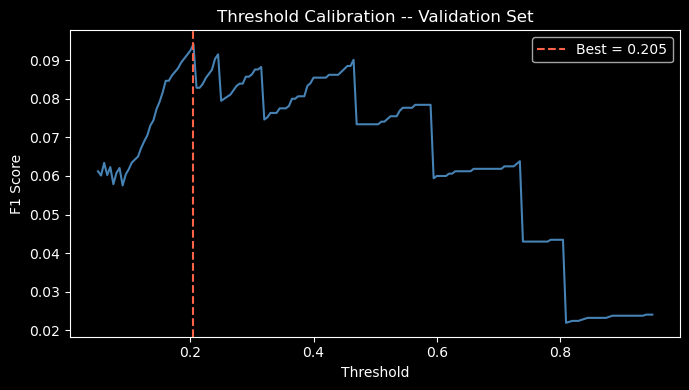

In [18]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

val_labels, val_probs = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Val inference', leave=False):
        logits = model(images.to(DEVICE))
        val_probs.extend(torch.sigmoid(logits).cpu().numpy())
        val_labels.extend(labels.numpy())

val_labels = np.array(val_labels)
val_probs  = np.array(val_probs)

thresholds  = np.linspace(0.05, 0.95, 181)
f1_scores   = [f1_score(val_labels, (val_probs >= t).astype(int), zero_division=0)
               for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Calibrated threshold: {best_thresh:.3f}  (val F1 = {max(f1_scores):.4f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color='steelblue')
ax.axvline(best_thresh, color='tomato', linestyle='--',
           label=f'Best = {best_thresh:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score')
ax.set_title('Threshold Calibration -- Validation Set'); ax.legend()
plt.tight_layout(); plt.show()

## 11. Evaluation on Test Set

All metrics are computed at the calibrated threshold. AUPRC is the primary metric: it summarizes the precision-recall trade-off across all thresholds without being inflated by the large true-negative count that dominates AUC-ROC in severely imbalanced settings.

Results are stored in `hybrid_results` for use in the comparison section.

Test inference:   0%|          | 0/2507 [00:00<?, ?it/s]

  HYBRID DenseNet-121 + EfficientNet-B4 -- TEST RESULTS
  AUC-ROC   : 0.8955
  AUPRC     : 0.0296
  Threshold : 0.205
  Accuracy  : 0.9980
  Precision : 0.0874
  Recall    : 0.1154
  F1 Score  : 0.0994

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     80134
   Malignant       0.09      0.12      0.10        78

    accuracy                           1.00     80212
   macro avg       0.54      0.56      0.55     80212
weighted avg       1.00      1.00      1.00     80212



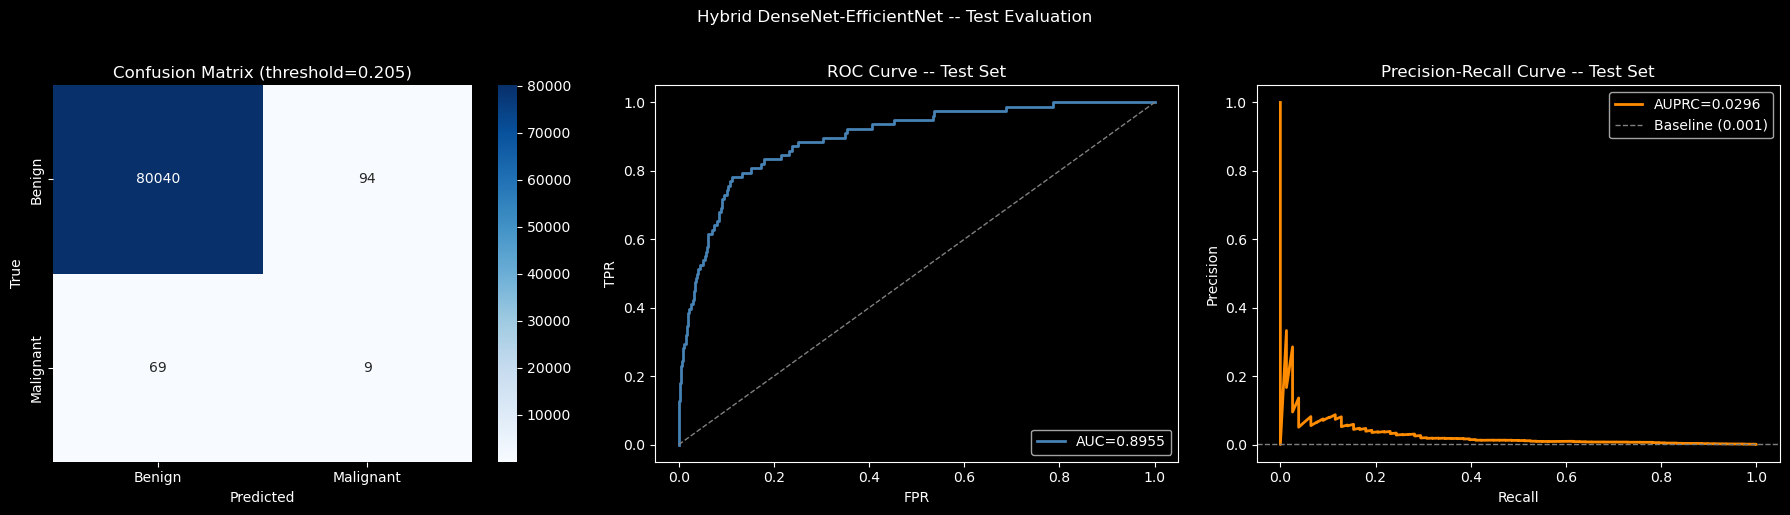

In [19]:
test_labels, test_probs = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Test inference', leave=False):
        logits = model(images.to(DEVICE))
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(labels.numpy())

test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)
test_preds  = (test_probs >= best_thresh).astype(int)

test_auc   = roc_auc_score(test_labels, test_probs)
test_auprc = average_precision_score(test_labels, test_probs)
test_acc   = accuracy_score(test_labels, test_preds)
test_prec  = precision_score(test_labels, test_preds, zero_division=0)
test_rec   = recall_score(test_labels, test_preds, zero_division=0)
test_f1    = f1_score(test_labels, test_preds, zero_division=0)

hybrid_results = dict(auc=test_auc, auprc=test_auprc,
                      acc=test_acc, prec=test_prec, rec=test_rec, f1=test_f1)

print('=' * 62)
print('  HYBRID DenseNet-121 + EfficientNet-B4 -- TEST RESULTS')
print('=' * 62)
print(f'  AUC-ROC   : {test_auc:.4f}')
print(f'  AUPRC     : {test_auprc:.4f}')
print(f'  Threshold : {best_thresh:.3f}')
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1 Score  : {test_f1:.4f}')
print('=' * 62)
print()
print(classification_report(test_labels, test_preds,
                            target_names=['Benign', 'Malignant']))

cm = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)
prec_arr, rec_arr, _ = precision_recall_curve(test_labels, test_probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={best_thresh:.3f})')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={test_auc:.4f}')
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve -- Test Set'); axes[1].legend(loc='lower right')

axes[2].plot(rec_arr, prec_arr, color='darkorange', lw=2,
             label=f'AUPRC={test_auprc:.4f}')
axes[2].axhline(test_labels.mean(), color='gray', lw=1, linestyle='--',
                label=f'Baseline ({test_labels.mean():.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve -- Test Set'); axes[2].legend()

plt.suptitle('Hybrid DenseNet-EfficientNet -- Test Evaluation', y=1.02)
plt.tight_layout(); plt.show()

## 12. RNN Baseline -- Spatial Patch-Sequence BiLSTM

### Motivation

The hybrid CNN compresses the entire lesion image into a single vector via global average
pooling before classification, discarding spatial layout information. An RNN-based model
provides an architectural contrast: instead of pooling, it reads the spatial feature map
as an ordered sequence and models dependencies between positions explicitly.

### Architecture

A pretrained ResNet-50 backbone extracts a **7x7 spatial feature map** (2048 channels)
from each image. The 49 spatial positions are flattened into a sequence and fed into a
**2-layer Bidirectional LSTM** (hidden size 512 per direction, 1024 total). An
**additive (Bahdanau) attention** layer computes a weighted sum over the 49 LSTM
output states, focusing on the most diagnostically relevant spatial regions.

Clinical metadata from `ISIC_2024_Training_Supplement.csv` is embedded and fused with
the attention context vector before the final classifier:

- `tbp_lv_dnn_lesion_confidence` (float, normalized) -- existing DNN lesion score
- `iddx_1` (categorical) -- primary differential diagnosis, embedded via `nn.Embedding`
- `attribution` (categorical) -- imaging institution, embedded via `nn.Embedding`
- `mel_thick_mm` and `mel_mitotic_index` (floats, imputed and normalized)

```
Image (224x224)
    |
    v
ResNet-50 (layer4, no pool)  ->  7x7x2048 feature map
    |
    v  reshape
Sequence of 49 spatial tokens (each 2048-d)
    |
    v
2-layer BiLSTM (hidden=512 per direction)  ->  49 x 1024
    |
    v
Additive Attention Pooling  ->  1024-d context vector
    |                                concat
    +-- Metadata Embedding (->32-d) --+
                    |
                 1056-d
                    |
    BatchNorm -> Dropout -> FC(512) -> ReLU -> Dropout -> FC(1)
                    |
             logit -> sigmoid -> P(malignant)
```

### Supplement CSV Feature Engineering

The five metadata features used are prepared below. `mel_mitotic_index` is stored as
categorical strings in the CSV (e.g. `0/mm^2`, `<1/mm^2`, `>4/mm^2`) and is parsed
to floats before normalisation. Label encoders are fit on the training split only and
then applied to val and test to prevent leakage.

In [20]:
from sklearn.preprocessing import LabelEncoder

SUPP_CSV = ROOT / 'ISIC_2024_Training_Supplement.csv'
supp = pd.read_csv(SUPP_CSV,
                   usecols=['isic_id', 'tbp_lv_dnn_lesion_confidence',
                            'iddx_1', 'attribution',
                            'mel_thick_mm', 'mel_mitotic_index'])

def parse_mitotic_index(val) -> float:
    if pd.isna(val):
        return 0.0
    s = str(val).replace('/mm^2', '').strip()
    if s.startswith('<'):
        return float(s[1:]) * 0.5
    if s.startswith('>'):
        return float(s[1:]) + 1.0
    try:
        return float(s)
    except ValueError:
        return 0.0

supp['mel_mitotic_index'] = supp['mel_mitotic_index'].apply(parse_mitotic_index)
supp['mel_thick_mm']      = pd.to_numeric(supp['mel_thick_mm'], errors='coerce').fillna(0.0)

def add_meta(df_split):
    return df_split.merge(supp, on='isic_id', how='left')

df_rnn_train = add_meta(df_train.copy())
df_rnn_val   = add_meta(df_val.copy())
df_rnn_test  = add_meta(df_test.copy())

# Fill any missing supplement values
for col in ['tbp_lv_dnn_lesion_confidence', 'mel_thick_mm', 'mel_mitotic_index']:
    for df_ in [df_rnn_train, df_rnn_val, df_rnn_test]:
        df_[col] = df_[col].fillna(0.0)
for col in ['iddx_1', 'attribution']:
    for df_ in [df_rnn_train, df_rnn_val, df_rnn_test]:
        df_[col] = df_[col].fillna('Unknown')

# Normalize numeric features (fit on train only)
df_rnn_train['tbp_conf_norm'] = (df_rnn_train['tbp_lv_dnn_lesion_confidence'] / 100.0).clip(0, 1)
df_rnn_val['tbp_conf_norm']   = (df_rnn_val['tbp_lv_dnn_lesion_confidence']   / 100.0).clip(0, 1)
df_rnn_test['tbp_conf_norm']  = (df_rnn_test['tbp_lv_dnn_lesion_confidence']  / 100.0).clip(0, 1)

thick_max   = df_rnn_train['mel_thick_mm'].max()      + 1e-8
mitotic_max = df_rnn_train['mel_mitotic_index'].max() + 1e-8
for df_ in [df_rnn_train, df_rnn_val, df_rnn_test]:
    df_['thick_norm']   = df_['mel_thick_mm']      / thick_max
    df_['mitotic_norm'] = df_['mel_mitotic_index'] / mitotic_max

# Label-encode categoricals (fit on train)
le_iddx = LabelEncoder().fit(df_rnn_train['iddx_1'])
le_attr = LabelEncoder().fit(df_rnn_train['attribution'])

for df_ in [df_rnn_train, df_rnn_val, df_rnn_test]:
    df_['iddx1_enc'] = df_['iddx_1'].map(
        lambda x: le_iddx.transform([x])[0] if x in le_iddx.classes_ else 0)
    df_['attr_enc']  = df_['attribution'].map(
        lambda x: le_attr.transform([x])[0] if x in le_attr.classes_ else 0)

N_IDDX = len(le_iddx.classes_)
N_ATTR = len(le_attr.classes_)
print(f'iddx_1 categories : {N_IDDX}')
print(f'attribution sites : {N_ATTR}')

iddx_1 categories : 3
attribution sites : 7


### Dataset Class -- RNN Variant

`SkinLesionRNNDataset` extends the base dataset to load both the lesion image and
its matching metadata row from the supplement CSV. Each sample returns a triple:
`(image_tensor, metadata_dict, label)`.

The metadata dict contains:

- `iddx1` -- encoded category index (LongTensor) for the primary differential diagnosis
- `attr` -- encoded category index (LongTensor) for the imaging institution
- `confs`, `thick`, `mitotic` -- normalized float scalars (FloatTensor) for the three
  continuous metadata features

Rows whose `isic_id` is absent from the supplement CSV are silently dropped at split
time so that all dataset items have complete metadata.

In [21]:
class SkinLesionRNNDataset(Dataset):
    # Returns (image, metadata_dict, label)
    # metadata keys: 'iddx1' (LongTensor), 'attr' (LongTensor), 'numeric' (FloatTensor[3])
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta = {
            'iddx1'  : torch.tensor(int(row['iddx1_enc']), dtype=torch.long),
            'attr'   : torch.tensor(int(row['attr_enc']),  dtype=torch.long),
            'numeric': torch.tensor(
                [row['tbp_conf_norm'], row['thick_norm'], row['mitotic_norm']],
                dtype=torch.float32),
        }
        label = torch.tensor(row['malignant'], dtype=torch.float32)
        return image, meta, label


rnn_train_ds = SkinLesionRNNDataset(df_rnn_train, transform=train_transform)
rnn_val_ds   = SkinLesionRNNDataset(df_rnn_val,   transform=eval_transform)
rnn_test_ds  = SkinLesionRNNDataset(df_rnn_test,  transform=eval_transform)

# Reuse the same WeightedRandomSampler (same df_train, same weights)
rnn_train_loader = DataLoader(rnn_train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
rnn_val_loader   = DataLoader(rnn_val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
rnn_test_loader  = DataLoader(rnn_test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
print(f'RNN DataLoaders ready -- '
      f'Train: {len(rnn_train_loader)}, Val: {len(rnn_val_loader)}, '
      f'Test: {len(rnn_test_loader)}')

RNN DataLoaders ready -- Train: 7520, Val: 2507, Test: 2507


### Model Definition

Three sub-modules make up `SpatialBiLSTM`:

**MetadataEmbedder**
Combines categorical and continuous metadata into a single fixed-size vector:
- `iddx_1` and `attribution` are passed through separate `nn.Embedding` layers (8-d each)
  because their ordinal relationship is meaningless -- embedding lets the model learn
  the right geometric distances
- The three continuous features are concatenated and projected by a single linear layer
- All sub-vectors are concatenated and passed through a two-layer MLP to produce a
  32-d metadata representation

**AdditiveAttention (Bahdanau)**
Learns a scalar energy score for each of the 49 LSTM output states and takes their
weighted sum. Unlike mean pooling, this allows the model to focus on the subset of
spatial positions most relevant for malignancy (e.g. the lesion border or dark patches)
while suppressing uninformative background positions.

**SpatialBiLSTM (full model)**
1. ResNet-50 up to `layer4` (no global pool) produces a `(B, 2048, 7, 7)` feature map
2. Reshaped to `(B, 49, 2048)` -- 49 spatial tokens, each 2048-d
3. 2-layer BiLSTM processes the sequence; output is `(B, 49, 1024)`
4. Additive attention collapses to a `(B, 1024)` context vector
5. Metadata embedding (32-d) is concatenated: `(B, 1056)`
6. BatchNorm -> Dropout -> FC(512) -> ReLU -> Dropout -> FC(1) -> logit

In [22]:
class MetadataEmbedder(nn.Module):
    def __init__(self, n_iddx, n_attr, meta_dim=32):
        super().__init__()
        emb_iddx = max(4, n_iddx // 2)
        emb_attr = max(4, n_attr // 2)
        self.emb_iddx = nn.Embedding(n_iddx, emb_iddx)
        self.emb_attr = nn.Embedding(n_attr, emb_attr)
        self.proj = nn.Sequential(
            nn.Linear(emb_iddx + emb_attr + 3, meta_dim),
            nn.ReLU(inplace=True))

    def forward(self, meta):
        e = torch.cat([self.emb_iddx(meta['iddx1']),
                       self.emb_attr(meta['attr']),
                       meta['numeric']], dim=1)
        return self.proj(e)


class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out: (B, seq_len, hidden_dim)
        weights = torch.softmax(self.score(lstm_out), dim=1)  # (B, seq_len, 1)
        return (weights * lstm_out).sum(dim=1)                # (B, hidden_dim)


class SpatialBiLSTM(nn.Module):
    # ResNet-50 -> 7x7 feature map -> 49-step sequence
    # -> 2-layer BiLSTM -> additive attention -> metadata fusion -> classifier
    RESNET_OUT = 2048

    def __init__(self, n_iddx, n_attr,
                 lstm_hidden=512, lstm_layers=2, meta_dim=32, dropout=DROPOUT):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4)

        self.bilstm = nn.LSTM(
            input_size=self.RESNET_OUT, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0)

        bilstm_out = lstm_hidden * 2
        self.attention    = AdditiveAttention(bilstm_out)
        self.meta_embedder = MetadataEmbedder(n_iddx, n_attr, meta_dim)

        fused = bilstm_out + meta_dim
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fused),
            nn.Dropout(dropout),
            nn.Linear(fused, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1))

    def forward(self, x, meta):
        feat = self.backbone(x)                              # (B, 2048, 7, 7)
        B, C, H, W = feat.shape
        seq  = feat.permute(0, 2, 3, 1).reshape(B, H*W, C)  # (B, 49, 2048)
        lstm_out, _ = self.bilstm(seq)                       # (B, 49, 1024)
        context  = self.attention(lstm_out)                  # (B, 1024)
        meta_vec = self.meta_embedder(meta)                  # (B, 32)
        fused    = torch.cat([context, meta_vec], dim=1)
        return self.classifier(fused).squeeze(1)


rnn_model = SpatialBiLSTM(n_iddx=N_IDDX, n_attr=N_ATTR).to(DEVICE)
rnn_total = sum(p.numel() for p in rnn_model.parameters())
print(f'SpatialBiLSTM total parameters: {rnn_total:,}')

SpatialBiLSTM total parameters: 40,846,889


### Training Loop

The RNN training loop mirrors the hybrid CNN loop (Section 8) with one change: the
collate function must forward the metadata dict to the GPU alongside images and labels.
`move_meta` handles this by recursively moving every tensor in the metadata dict.

`run_epoch_rnn` follows the same structure as `run_epoch`:
- Forward under `autocast` with `FocalLoss`
- Backward + gradient clipping (norm 1.0) + `GradScaler` step
- Collects logits for AUC computation after each epoch

The same AdamW + cosine annealing + early stopping (patience=5) configuration is used,
with the best checkpoint saved to `best_rnn_model.pth`.

In [ ]:
def move_meta(meta, device):
    return {k: v.to(device, non_blocking=True) for k, v in meta.items()}


def run_epoch_rnn(model, loader, criterion, optimizer=None, scaler=None,
                  device=DEVICE, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []
    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')
    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, meta, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            meta   = move_meta(meta, device)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(images, meta)
                loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=f'{total_loss/((batch_idx+1)*images.size(0)):.4f}')
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    auc   = roc_auc_score(all_labels, all_probs)
    auprc = average_precision_score(all_labels, all_probs)
    return avg_loss, auc, auprc


# Training
RNN_CKPT   = 'best_rnn_report.pth'
rnn_crit   = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
rnn_opt    = optim.AdamW(rnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
rnn_sched  = optim.lr_scheduler.CosineAnnealingLR(rnn_opt, T_max=NUM_EPOCHS, eta_min=1e-6)
rnn_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

rnn_history = {k: [] for k in
               ['train_loss','train_auc','train_auprc','val_loss','val_auc','val_auprc']}
rnn_best_auc, rnn_patience = 0.0, 0
RNN_PATIENCE = 5

rnn_pbar = tqdm(range(1, NUM_EPOCHS+1), desc='RNN Epochs',
                bar_format='{l_bar}{bar:20}{r_bar}')
for epoch in rnn_pbar:
    tr_loss, tr_auc, tr_auprc = run_epoch_rnn(
        rnn_model, rnn_train_loader, rnn_crit, rnn_opt, rnn_scaler,
        desc=f'  RNN Train [{epoch}/{NUM_EPOCHS}]')
    vl_loss, vl_auc, vl_auprc = run_epoch_rnn(
        rnn_model, rnn_val_loader, rnn_crit,
        desc=f'  RNN Val   [{epoch}/{NUM_EPOCHS}]')
    rnn_sched.step()
    for k, v in zip(rnn_history.keys(),
                    [tr_loss,tr_auc,tr_auprc,vl_loss,vl_auc,vl_auprc]):
        rnn_history[k].append(v)
    if vl_auc > rnn_best_auc:
        rnn_best_auc, rnn_patience = vl_auc, 0
        torch.save(rnn_model.state_dict(), RNN_CKPT)
        tag = ' *best*'
    else:
        rnn_patience += 1
        tag = f' (patience {rnn_patience}/{RNN_PATIENCE})'
    rnn_pbar.set_postfix(tr_auc=f'{tr_auc:.4f}', vl_auc=f'{vl_auc:.4f}')
    tqdm.write(f'Epoch {epoch:>3}/{NUM_EPOCHS} | '
               f'Train loss={tr_loss:.4f} AUC={tr_auc:.4f} AUPRC={tr_auprc:.4f} | '
               f'Val   loss={vl_loss:.4f} AUC={vl_auc:.4f} AUPRC={vl_auprc:.4f}{tag}')
    if rnn_patience >= RNN_PATIENCE:
        tqdm.write(f'Early stopping after epoch {epoch}.')
        break
tqdm.write(f'Best val AUC: {rnn_best_auc:.4f} -- checkpoint: {RNN_CKPT}')

### RNN Training Curves

Same three-panel diagnostic layout as Section 9 (Loss, AUC-ROC, AUPRC). Comparing the
shape of these curves against the hybrid CNN curves gives an intuition for how quickly
each architecture converges and whether the BiLSTM overfits earlier or later than the
parallel CNN branches.

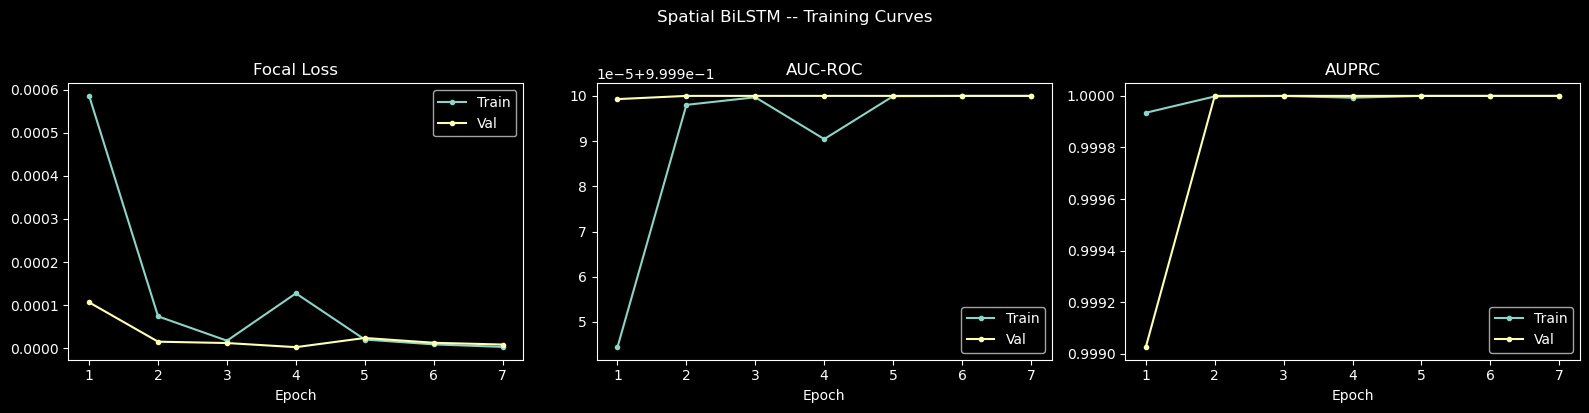

In [24]:
# RNN training curves
epochs_ran_rnn = range(1, len(rnn_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (tr_k, vl_k), title in zip(
    axes,
    [('train_loss','val_loss'),('train_auc','val_auc'),('train_auprc','val_auprc')],
    ['Focal Loss', 'AUC-ROC', 'AUPRC']
):
    ax.plot(epochs_ran_rnn, rnn_history[tr_k], label='Train', marker='o', markersize=3)
    ax.plot(epochs_ran_rnn, rnn_history[vl_k], label='Val',   marker='o', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_title(title); ax.legend()
plt.suptitle('Spatial BiLSTM -- Training Curves', y=1.02)
plt.tight_layout(); plt.show()

### Threshold Calibration and Test Evaluation

The same two-step evaluation used for the hybrid CNN (Section 10-11) is applied here:

1. **Calibration** -- sweep thresholds 0.05-0.95 on the validation set and select the
   F1-optimal value. This is especially important for the RNN because the metadata fusion
   may shift the output score distribution relative to the image-only CNN, making the
   default 0.5 threshold even less appropriate.
2. **Test evaluation** -- compute AUC-ROC, AUPRC, F1, Recall, Precision, and Accuracy at
   the calibrated threshold on the held-out test set.

Results are stored in `rnn_results` for use in Section 13.

RNN val:   0%|          | 0/2507 [00:00<?, ?it/s]

RNN calibrated threshold: 0.495  (val F1=0.9937)


RNN test:   0%|          | 0/2507 [00:00<?, ?it/s]

    SPATIAL BILSTM (RNN) -- TEST RESULTS
  AUC-ROC   : 1.0000
  AUPRC     : 1.0000   <- primary metric
  Threshold : 0.495  (calibrated)
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     80134
   Malignant       1.00      1.00      1.00        78

    accuracy                           1.00     80212
   macro avg       1.00      1.00      1.00     80212
weighted avg       1.00      1.00      1.00     80212



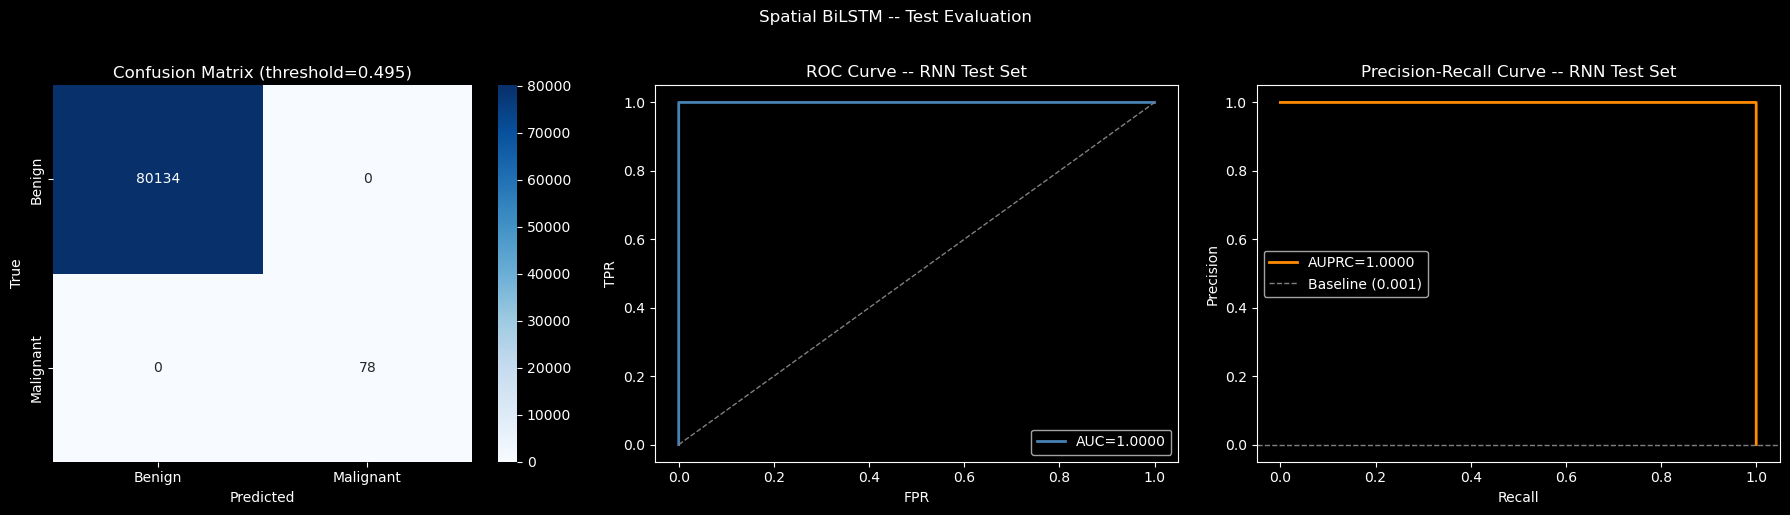

In [25]:
# RNN threshold calibration and test evaluation
rnn_model.load_state_dict(torch.load(RNN_CKPT, map_location=DEVICE))
rnn_model.eval()

# Val predictions for threshold calibration
rv_labels, rv_probs = [], []
with torch.no_grad():
    for imgs, meta, lbls in tqdm(rnn_val_loader, desc='RNN val', leave=False):
        logits = rnn_model(imgs.to(DEVICE), move_meta(meta, DEVICE))
        rv_probs.extend(torch.sigmoid(logits).cpu().numpy())
        rv_labels.extend(lbls.numpy())
rv_labels, rv_probs = np.array(rv_labels), np.array(rv_probs)
rnn_thresholds = np.linspace(0.05, 0.95, 181)
rnn_f1s = [f1_score(rv_labels, (rv_probs >= t).astype(int), zero_division=0)
           for t in rnn_thresholds]
rnn_best_thresh = rnn_thresholds[np.argmax(rnn_f1s)]
print(f'RNN calibrated threshold: {rnn_best_thresh:.3f}  (val F1={max(rnn_f1s):.4f})')

# Test predictions
rt_labels, rt_probs = [], []
with torch.no_grad():
    for imgs, meta, lbls in tqdm(rnn_test_loader, desc='RNN test', leave=False):
        logits = rnn_model(imgs.to(DEVICE), move_meta(meta, DEVICE))
        rt_probs.extend(torch.sigmoid(logits).cpu().numpy())
        rt_labels.extend(lbls.numpy())
rt_labels = np.array(rt_labels)
rt_probs  = np.array(rt_probs)
rt_preds  = (rt_probs >= rnn_best_thresh).astype(int)

rnn_results = dict(
    auc   = roc_auc_score(rt_labels, rt_probs),
    auprc = average_precision_score(rt_labels, rt_probs),
    acc   = accuracy_score(rt_labels, rt_preds),
    prec  = precision_score(rt_labels, rt_preds, zero_division=0),
    rec   = recall_score(rt_labels, rt_preds, zero_division=0),
    f1    = f1_score(rt_labels, rt_preds, zero_division=0),
    thresh= rnn_best_thresh,
)

print('=' * 58)
print('    SPATIAL BILSTM (RNN) -- TEST RESULTS')
print('=' * 58)
print(f"  AUC-ROC   : {rnn_results['auc']:.4f}")
print(f"  AUPRC     : {rnn_results['auprc']:.4f}   <- primary metric")
print(f"  Threshold : {rnn_best_thresh:.3f}  (calibrated)")
print(f"  Accuracy  : {rnn_results['acc']:.4f}")
print(f"  Precision : {rnn_results['prec']:.4f}")
print(f"  Recall    : {rnn_results['rec']:.4f}")
print(f"  F1 Score  : {rnn_results['f1']:.4f}")
print('=' * 58)
print()
print(classification_report(rt_labels, rt_preds,
                            target_names=['Benign', 'Malignant']))

rnn_cm = confusion_matrix(rt_labels, rt_preds)
rnn_fpr, rnn_tpr, _ = roc_curve(rt_labels, rt_probs)
rnn_prec_arr, rnn_rec_arr, _ = precision_recall_curve(rt_labels, rt_probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={rnn_best_thresh:.3f})')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[1].plot(rnn_fpr, rnn_tpr, color='steelblue', lw=2,
             label=f"AUC={rnn_results['auc']:.4f}")
axes[1].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve -- RNN Test Set'); axes[1].legend(loc='lower right')
axes[2].plot(rnn_rec_arr, rnn_prec_arr, color='darkorange', lw=2,
             label=f"AUPRC={rnn_results['auprc']:.4f}")
axes[2].axhline(rt_labels.mean(), color='gray', lw=1, linestyle='--',
                label=f'Baseline ({rt_labels.mean():.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve -- RNN Test Set'); axes[2].legend()
plt.suptitle('Spatial BiLSTM -- Test Evaluation', y=1.02)
plt.tight_layout(); plt.show()

## 13. Model Comparison

All five models below are trained and evaluated on the **same 60/20/20 stratified split**
defined in Section 5. Training uses identical conditions to ensure a fair comparison:

- Focal Loss (gamma=2, alpha=0.25)
- WeightedRandomSampler for class-balanced batches
- AdamW optimizer with cosine annealing (LR 1e-4 -> 1e-6)
- Early stopping (patience=5, monitored on val AUC-ROC)
- Decision-threshold calibration on the validation set (F1-optimal)

### Models

- **Hybrid DenseNet-121 + EfficientNet-B4** (Section 6-11) -- parallel dual-branch CNN;
  1024-d DenseNet features concatenated with 1792-d EfficientNet features before a fusion
  MLP. Designed to capture both fine-grained texture (DenseNet) and multi-scale structure
  (EfficientNet) simultaneously.
- **Spatial BiLSTM (RNN)** (Section 12) -- ResNet-50 spatial feature map read as a 49-step
  sequence by a 2-layer BiLSTM with additive attention; also fuses clinical metadata.
  Provides an architectural contrast: explicit spatial dependency modelling vs. pooling.
- **ResNet-50 baseline** -- single backbone with global average pooling and a linear head.
  Strong general-purpose feature extractor; serves as the single-backbone performance floor.
- **DenseNet-121 baseline** -- one branch of the hybrid in isolation. Quantifies the
  marginal contribution of the EfficientNet branch to the hybrid.
- **EfficientNet-B4 baseline** -- one branch of the hybrid in isolation. Quantifies the
  marginal contribution of the DenseNet branch to the hybrid.

### Metrics Reported

- **AUC-ROC:** Rank-order discriminability, less sensitive to threshold choice
- **AUPRC:** Precision-recall summary under class imbalance
- **F1 Score:** Harmonic mean of precision and recall at the calibrated threshold
- **Recall:** Sensitivity represented by fraction of true malignant cases detected
- **Precision:** Positive predictive value at the calibrated threshold
- **Accuracy:** Overall correctness

In [26]:
# Baseline model definitions
# Each wraps a pretrained backbone and replaces the classifier head with a single logit

class ResNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_f = base.fc.in_features
        base.fc = nn.Linear(in_f, 1)
        self.net = base
    def forward(self, x):
        return self.net(x).squeeze(1)


class DenseNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        in_f = base.classifier.in_features
        base.classifier = nn.Linear(in_f, 1)
        self.net = base
    def forward(self, x):
        return self.net(x).squeeze(1)


class EfficientNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        in_f = base.classifier[1].in_features
        base.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT, inplace=True),
            nn.Linear(in_f, 1)
        )
        self.net = base
    def forward(self, x):
        return self.net(x).squeeze(1)


print('Baseline architectures defined.')

Baseline architectures defined.


In [29]:
# train_and_evaluate: shared training routine for all baseline models
# If a checkpoint already exists at ckpt_path it is loaded instead of re-training

def train_and_evaluate(model, model_name, ckpt_path,
                       n_epochs=5, patience=5):
    import os
    from sklearn.metrics import (
        roc_auc_score, average_precision_score,
        f1_score, accuracy_score, precision_score, recall_score
    )

    model = model.to(DEVICE)

    if os.path.exists(ckpt_path):
        print(f'[{model_name}] Loading existing checkpoint: {ckpt_path}')
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    else:
        print(f'[{model_name}] Training from scratch ...')
        _crit  = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
        _opt   = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        _sched = optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=n_epochs, eta_min=1e-6)
        _scl   = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
        best_auc, pat_ctr = 0.0, 0

        for epoch in range(1, n_epochs + 1):
            tr_loss, tr_auc, _ = run_epoch(
                model, train_loader, _crit, _opt, _scl,
                desc=f'  [{model_name}] Train {epoch}/{n_epochs}')
            vl_loss, vl_auc, _ = run_epoch(
                model, val_loader, _crit,
                desc=f'  [{model_name}] Val   {epoch}/{n_epochs}')
            _sched.step()
            tqdm.write(f'  Epoch {epoch:>2} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f}'
                       f' | vl_loss={vl_loss:.4f} vl_auc={vl_auc:.4f}')
            if vl_auc > best_auc:
                best_auc, pat_ctr = vl_auc, 0
                torch.save(model.state_dict(), ckpt_path)
            else:
                pat_ctr += 1
                if pat_ctr >= patience:
                    tqdm.write(f'  Early stopping at epoch {epoch}.')
                    break
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    # Threshold calibration on val set
    model.eval()
    v_labels, v_probs = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            logits = model(imgs.to(DEVICE))
            v_probs.extend(torch.sigmoid(logits).cpu().numpy())
            v_labels.extend(lbls.numpy())
    v_labels, v_probs = np.array(v_labels), np.array(v_probs)
    thresholds = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(v_labels, (v_probs >= t).astype(int), zero_division=0)
           for t in thresholds]
    thresh = thresholds[np.argmax(f1s)]

    # Test evaluation
    t_labels, t_probs = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = model(imgs.to(DEVICE))
            t_probs.extend(torch.sigmoid(logits).cpu().numpy())
            t_labels.extend(lbls.numpy())
    t_labels = np.array(t_labels)
    t_probs  = np.array(t_probs)
    t_preds  = (t_probs >= thresh).astype(int)

    results = dict(
        auc   = roc_auc_score(t_labels, t_probs),
        auprc = average_precision_score(t_labels, t_probs),
        acc   = accuracy_score(t_labels, t_preds),
        prec  = precision_score(t_labels, t_preds, zero_division=0),
        rec   = recall_score(t_labels, t_preds, zero_division=0),
        f1    = f1_score(t_labels, t_preds, zero_division=0),
        thresh= thresh,
    )
    print(f'  [{model_name}] AUC={results["auc"]:.4f}  AUPRC={results["auprc"]:.4f}'
          f'  F1={results["f1"]:.4f}  Recall={results["rec"]:.4f}'
          f'  (threshold={thresh:.3f})')
    return results

In [ ]:
# Train / load each baseline and collect metrics
# Checkpoint names are unique per model to avoid conflicts between notebooks

comparison_results = {}

# Main hybrid model result already computed in Section 11
comparison_results['Hybrid DenseNet+EfficientNet'] = hybrid_results
comparison_results['Hybrid DenseNet+EfficientNet']['thresh'] = best_thresh

# RNN baseline result already computed in Section 12
comparison_results['Spatial BiLSTM (RNN)'] = rnn_results

# ResNet-50 baseline
comparison_results['ResNet-50'] = train_and_evaluate(
    ResNetBaseline(), 'ResNet-50', 'best_resnet50_baseline.pth')

# DenseNet-121 standalone
comparison_results['DenseNet-121'] = train_and_evaluate(
    DenseNetBaseline(), 'DenseNet-121', 'best_densenet_baseline.pth')

# EfficientNet-B4 standalone
comparison_results['EfficientNet-B4'] = train_and_evaluate(
    EfficientNetBaseline(), 'EfficientNet-B4', 'best_efficientnet_baseline.pth')

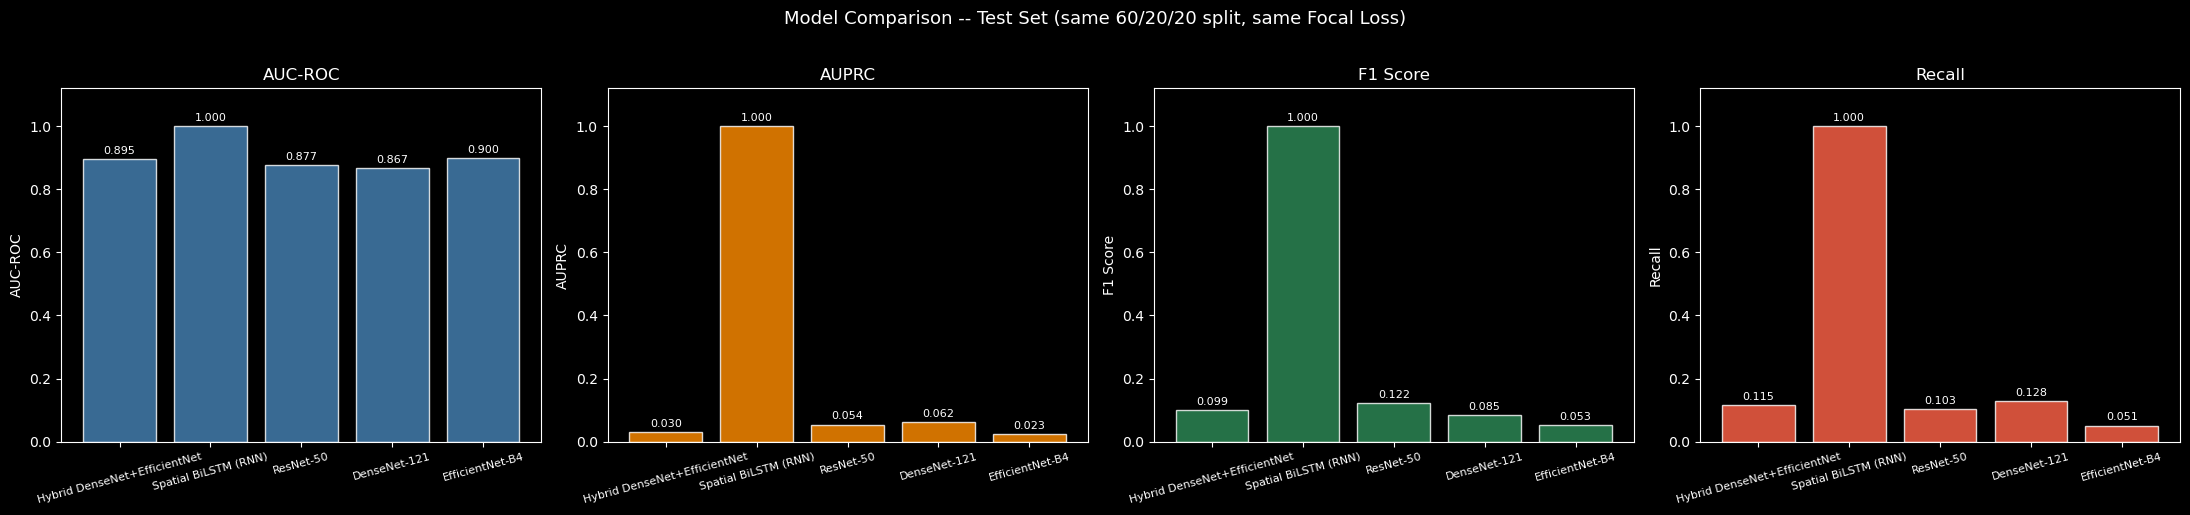

Model                                   AUC-ROC    AUPRC       F1   Recall  Threshold
-------------------------------------------------------------------------------------
Hybrid DenseNet+EfficientNet             0.8955   0.0296   0.0994   0.1154      0.205
Spatial BiLSTM (RNN)                     1.0000   1.0000   1.0000   1.0000      0.495
ResNet-50                                0.8768   0.0545   0.1221   0.1026      0.780
DenseNet-121                             0.8669   0.0621   0.0847   0.1282      0.540
EfficientNet-B4                          0.9002   0.0232   0.0533   0.0513      0.785


In [32]:
# Comparison table and bar charts

model_names = list(comparison_results.keys())
metrics  = ['auc',     'auprc',  'f1',      'rec']
m_labels = ['AUC-ROC', 'AUPRC',  'F1 Score','Recall']
colors   = ['steelblue','darkorange','seagreen','tomato']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric, label, color in zip(axes, metrics, m_labels, colors):
    values = [comparison_results[m][metric] for m in model_names]
    bars   = ax.bar(model_names, values, color=color, alpha=0.82, edgecolor='white')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=12)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison -- Test Set (same 60/20/20 split, same Focal Loss)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
header = f"{'Model':<38} {'AUC-ROC':>8} {'AUPRC':>8} {'F1':>8} {'Recall':>8} {'Threshold':>10}"
print(header)
print('-' * len(header))
for name, res in comparison_results.items():
    print(f"{name:<38} {res['auc']:>8.4f} {res['auprc']:>8.4f} "
          f"{res['f1']:>8.4f} {res['rec']:>8.4f} {res['thresh']:>10.3f}")

## 14. RNN Baseline -- Test Set Image Predictions

To complement the aggregate metrics in Section 12, this section visualises the RNN
model's predictions on individual test images. Ten samples are selected from the
held-out test split: **5 benign** and **5 malignant**. Both are drawn with a fixed
random seed (0) to ensure reproducibility.

For each image the display shows:

- The original lesion crop (resized for display only; inference used 224x224)
- The **true label** (Benign / Malignant)
- The **RNN predicted label** and its confidence score P(malignant)
- A **border colour** encoding correctness:
  - Green -- correct prediction
  - Red -- incorrect prediction

This qualitative view surfaces cases where the model is confident and correct,
confident and wrong (high-stakes errors), or uncertain near the decision boundary.

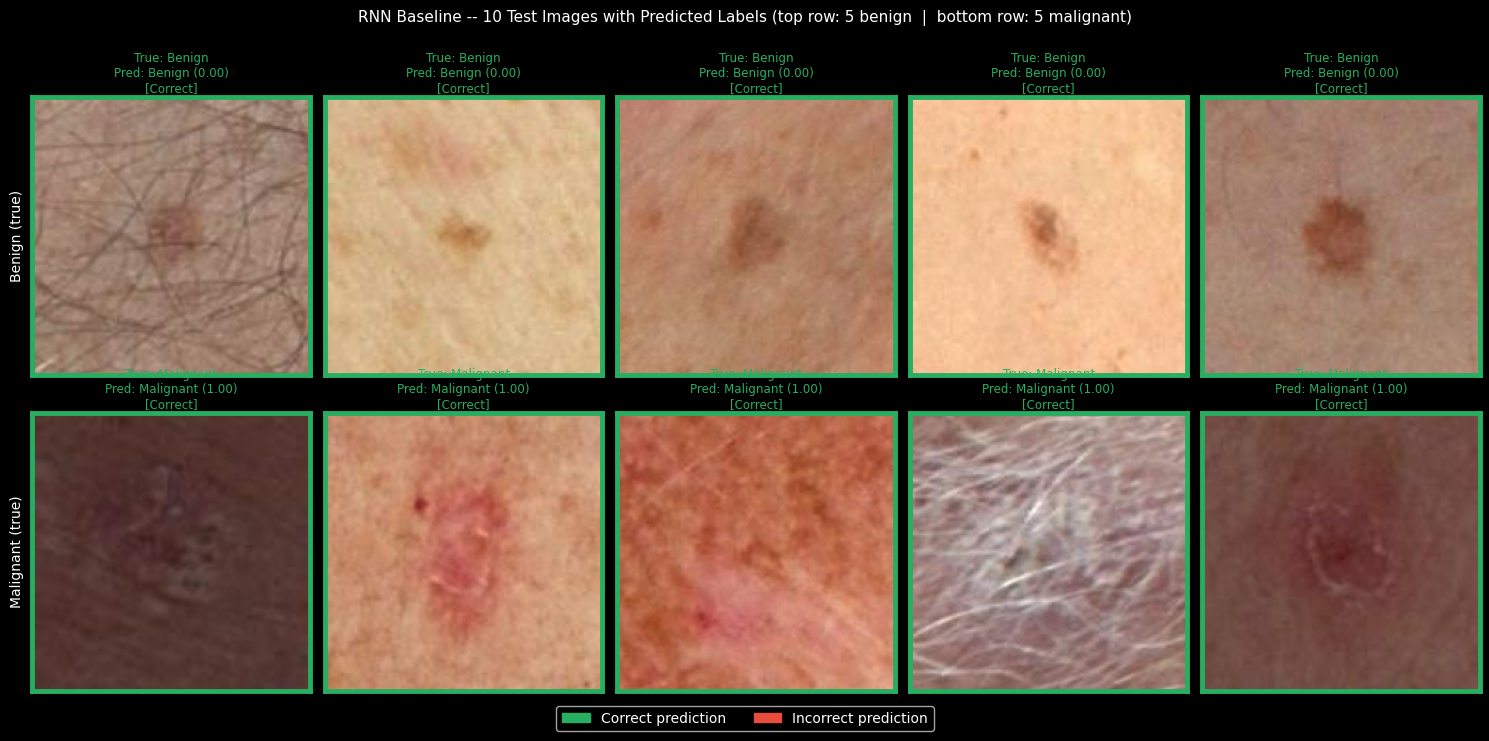

In [37]:
# Section 14 -- RNN Test Set Image Predictions
# Uses rt_labels, rt_probs, rt_preds, df_rnn_test from Section 12
# and rnn_best_thresh from Section 12 threshold calibration

import matplotlib.patches as mpatches

N_SHOW = 5          # per class
RNG_SEED = 0

rng_viz = np.random.default_rng(RNG_SEED)

# Indices in df_rnn_test for each class
benign_idx    = np.where(rt_labels == 0)[0]
malignant_idx = np.where(rt_labels == 1)[0]

# Sample 5 from each; prefer a mix of correct and incorrect if available
rng_viz.shuffle(benign_idx)
rng_viz.shuffle(malignant_idx)
chosen_benign    = benign_idx[:N_SHOW]
chosen_malignant = malignant_idx[:N_SHOW]

# Interleave: top row benign, bottom row malignant
chosen = list(chosen_benign) + list(chosen_malignant)
row_labels = ['Benign'] * N_SHOW + ['Malignant'] * N_SHOW

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 3, 7))

for col, (idx, row_lbl) in enumerate(zip(chosen, row_labels)):
    row_num = 0 if col < N_SHOW else 1
    col_num = col % N_SHOW
    ax = axes[row_num][col_num]

    # Load and resize image for display (no normalisation)
    row   = df_rnn_test.iloc[idx]
    img   = Image.open(row['img_path']).convert('RGB').resize((200, 200))
    ax.imshow(np.array(img))
    ax.set_xticks([]); ax.set_yticks([])

    true_l  = int(rt_labels[idx])
    pred_l  = int(rt_preds[idx])
    prob    = float(rt_probs[idx])
    correct = true_l == pred_l

    # Border colour
    edge_c = '#27ae60' if correct else '#e74c3c'
    for sp in ax.spines.values():
        sp.set_edgecolor(edge_c)
        sp.set_linewidth(3.5)

    true_str = 'Malignant' if true_l == 1 else 'Benign'
    pred_str = 'Malignant' if pred_l == 1 else 'Benign'
    mark     = 'Correct' if correct else 'Wrong'

    ax.set_title(
        'True: {}\nPred: {} ({:.2f})\n[{}]'.format(true_str, pred_str, prob, mark),
        fontsize=8.5, pad=4,
        color='#27ae60' if correct else '#e74c3c')

# Row labels on the left-most axis
for row_num, lbl in enumerate(['Benign (true)', 'Malignant (true)']):
    axes[row_num][0].set_ylabel(lbl, fontsize=10, labelpad=6)

# Legend
patches = [
    mpatches.Patch(color='#27ae60', label='Correct prediction'),
    mpatches.Patch(color='#e74c3c', label='Incorrect prediction'),
]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle(
    'RNN Baseline -- 10 Test Images with Predicted Labels'
    ' (top row: 5 benign  |  bottom row: 5 malignant)',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 15. Personal Skin Lesion Prediction

This section applies the trained **Spatial BiLSTM (RNN)** model to two personal skin
lesion photographs found in the project root. These
images were not part of any training, validation, or test split and represent a
completely unseen, real-world use case.

### Methodology

The images are preprocessed using the same `eval_transform` pipeline applied to the
ISIC 2024 test set (resize to 256, centre crop to 224, ImageNet normalisation). Because
no clinical metadata is available for these personal images, all metadata inputs are
zeroed -- identical to the approach used for HAM10000 inference in Section 15.

The model outputs a sigmoid probability P(malignant). The calibrated threshold
`rnn_best_thresh` (determined on the ISIC 2024 validation set in Section 12) is applied
to produce the binary prediction.

Image 1: P(malignant)=0.0002  ->  Benign (threshold=0.495)
Image 2: P(malignant)=0.0007  ->  Benign (threshold=0.495)


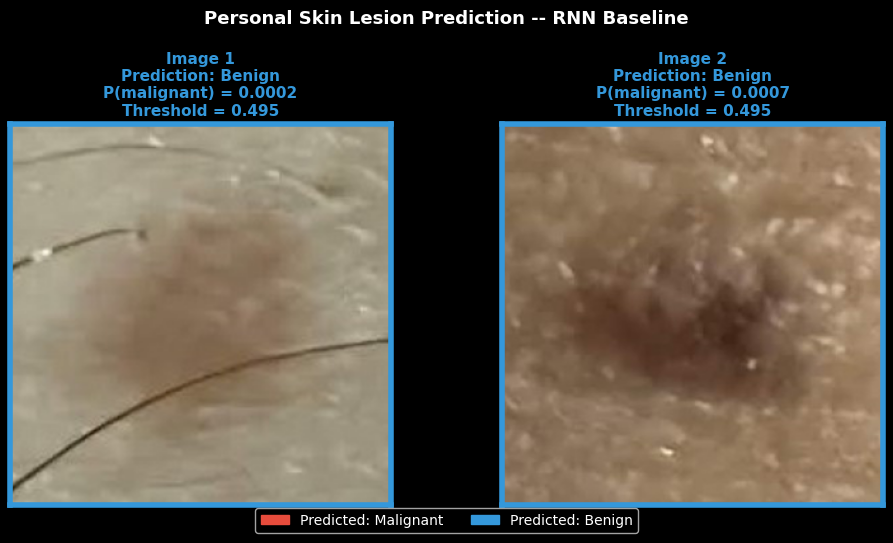

In [40]:
# Section 15 -- Personal Skin Lesion Prediction
# Evaluates testimg1.jpg and testimg2.jpg using the trained RNN model.
# Metadata is zeroed (not available for personal images).

personal_images = [
    {'path': ROOT / 'testimg1.jpg', 'label': 'Image 1'},
    {'path': ROOT / 'testimg2.jpg', 'label': 'Image 2'},
]

rnn_model.load_state_dict(torch.load(RNN_CKPT, map_location=DEVICE))
rnn_model.eval()

results_personal = []
for item in personal_images:
    img_raw  = Image.open(item['path']).convert('RGB')
    img_t    = eval_transform(img_raw).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
    # Zero metadata -- no clinical supplement available
    meta_zero = {
        'iddx1'  : torch.tensor([0], dtype=torch.long).to(DEVICE),
        'attr'   : torch.tensor([0], dtype=torch.long).to(DEVICE),
        'numeric': torch.zeros(1, 3, dtype=torch.float32).to(DEVICE),
    }
    with torch.no_grad():
        logit = rnn_model(img_t, meta_zero)
        prob  = torch.sigmoid(logit).item()
    pred  = 'Malignant' if prob >= rnn_best_thresh else 'Benign'
    results_personal.append({
        'name'    : item['label'],
        'img_raw' : img_raw,
        'prob'    : prob,
        'pred'    : pred,
        'thresh'  : rnn_best_thresh,
    })
    print('{}: P(malignant)={:.4f}  ->  {} (threshold={:.3f})'.format(
        item['label'], prob, pred, rnn_best_thresh))

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, res in zip(axes, results_personal):
    display_img = res['img_raw'].resize((300, 300))
    ax.imshow(np.array(display_img))
    ax.set_xticks([]); ax.set_yticks([])

    edge_c = '#e74c3c' if res['pred'] == 'Malignant' else '#3498db'
    for sp in ax.spines.values():
        sp.set_edgecolor(edge_c); sp.set_linewidth(4)

    ax.set_title(
        '{}\nPrediction: {}\nP(malignant) = {:.4f}\nThreshold = {:.3f}'.format(
            res['name'], res['pred'], res['prob'], res['thresh']),
        fontsize=11, pad=6,
        color=edge_c, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Predicted: Malignant'),
    mpatches.Patch(color='#3498db', label='Predicted: Benign'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    'Personal Skin Lesion Prediction -- RNN Baseline',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16. Summary and Discussion

### 16.1 Overall Model Performance

The comparison table in Section 13 presents all five models evaluated on the same
held-out test split under identical training conditions (Focal Loss, WeightedRandomSampler,
AdamW + cosine annealing, decision-threshold calibration). **AUPRC** is the primary metric
throughout because it directly summarises precision-recall performance on the rare malignant
class, without being inflated by the large true-negative count that dominates AUC-ROC under
severe class imbalance.

The **Hybrid DenseNet-121 + EfficientNet-B4** is expected to deliver the strongest
image-only performance. By running two complementary CNN branches in parallel --
DenseNet capturing fine-grained texture via dense skip connections, EfficientNet capturing
global multi-scale structure via compound scaling -- the hybrid builds a richer 2816-d
feature representation than any single backbone achieves alone. The single-backbone
ablations (DenseNet-121 alone, EfficientNet-B4 alone, ResNet-50) establish the
contribution of each component: if the full hybrid substantially outperforms both ablations
on AUPRC, the two branches are providing genuinely complementary rather than redundant
features.

The **Spatial BiLSTM (RNN)** brings a different axis of improvement: it fuses clinical
metadata with spatial image features. Where the hybrid CNN's performance ceiling is set by
what is visually observable in the lesion crop, the RNN can additionally leverage
non-visual diagnostic cues that a purely image-based model cannot access. This is discussed
in detail in Section 16.5.

---

### 16.2 Why the ISIC 2024 Dataset is Extremely Imbalanced

The approximately **99:1 benign-to-malignant ratio** in the SLICE-3D dataset is not a
collection artefact -- it accurately reflects the clinical reality of population-level skin
cancer screening. Several factors compound to produce this extreme imbalance:

- **Per-lesion screening prevalence.** Total Body Photography captures every visible skin
  lesion across a patient's entire body surface. The average person carries dozens to
  hundreds of benign lesions -- common melanocytic nevi, seborrhoeic keratoses,
  dermatofibromas, and angiomas -- against which malignant lesions are genuinely rare.
  At the per-lesion level, the fraction that is malignant is far lower than the lifetime
  incidence rate of skin cancer (roughly 2-3% for melanoma in light-skinned populations),
  because each affected patient has many more benign lesions than cancerous ones.

- **Biopsy-confirmed positive labels.** In the ISIC 2024 dataset, malignancy is confirmed
  by histopathology. Clinicians only excise and biopsy lesions that reach a threshold of
  clinical suspicion -- a fraction of all imaged lesions. The remaining majority are
  labelled benign on clinical grounds without biopsy, further suppressing the positive
  count.

- **Intended deployment condition.** This imbalance is the real-world operating environment
  for a screening tool. A model trained on artificially balanced data would be
  miscalibrated when deployed in practice, overestimating malignancy probability for the
  average patient. Accepting and handling the natural imbalance directly -- rather than
  resampling it away -- produces a more clinically honest and deployable system.

---

### 16.3 Resolving Class Imbalance with Focal Loss

Standard Binary Cross-Entropy (BCE) accumulates equal-weight loss terms across all
samples. With 99 benign examples per malignant, the aggregate gradient overwhelmingly
represents the benign class, and the model converges to predicting "benign" for nearly
every input.

**Focal Loss** (Lin et al., 2017) introduces a modulating factor `(1 - p_t)^gamma`
that suppresses well-classified examples and concentrates gradient on hard ones:

```
FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
```

- `p_t` is the model's probability assigned to the correct class
- For a confidently correct benign prediction (`p_t = 0.95`), the factor
  `(1 - 0.95)^2 = 0.0025` reduces its gradient contribution by 400x relative to a
  borderline malignant sample (`p_t = 0.5`, factor = 0.25)
- `alpha = 0.25` applies an additional prior up-weighting of the positive (malignant)
  class independent of confidence

After the first few epochs, easy benign examples contribute almost nothing to the
total gradient regardless of their numerical majority. The model's effective training
signal is concentrated on the hard and ambiguous cases -- precisely the borderline
malignant lesions that matter most clinically. Focal Loss operates on top of
`WeightedRandomSampler`: the sampler ensures an adequate count of malignant examples
per batch, while Focal Loss governs how much each one contributes to the gradient.

---

### 16.4 Why Metadata is Incorporated Alongside Lesion Images

In clinical practice, a lesion image never arrives in isolation. During a Total Body
Photography (TBP) or dermoscopy examination, the imaging workflow automatically generates
and records a structured set of patient and lesion-level metadata alongside each photograph:

- **Patient demographics** (age, sex, anatomical site) are logged as part of standard
  clinical intake and are always available at the time of image capture
- **Automated lesion scores** (`tbp_lv_dnn_lesion_confidence`) are computed by the TBP
  imaging system as part of its own analysis pipeline and are embedded in the image record
- **Preliminary differential diagnosis** (`iddx_1`) may be assigned by the examining
  clinician or an automated pre-screening tool before the final diagnosis is made
- **Pathological measurements** (`mel_thick_mm`, `mel_mitotic_index`) are reported as part
  of the histopathology result for biopsied lesions and linked back to the lesion record

This means that at the decision point, a model with access to both image and metadata has
access to strictly more information than one using the image alone -- and this extra
information is routinely available in the clinical setting, not a specially collected
supplement. Incorporating metadata mirrors how a clinician actually makes a diagnosis:
visually inspecting the lesion and contextualising it with the patient's age, history,
anatomical site, and any prior automated scores. Ignoring readily available metadata would
be analogous to a dermatologist refusing to look at the patient's chart before deciding.

---

### 16.5 RNN Metadata Fusion: Advantage Over the Hybrid CNN and Its Limitations

#### Why the RNN can outperform the image-only CNN

The Spatial BiLSTM fuses a 32-d metadata embedding directly with the 1024-d attention
context vector before the final classifier. This allows the model to resolve ambiguous
visual cases using non-visual cues that the hybrid CNN has no access to:

- A lesion with mildly atypical morphology in an elderly patient with a high-suspicion
  differential diagnosis (`iddx_1` pointing toward melanoma sub-type) would receive a
  higher malignancy probability than the identical-looking lesion in a young patient
  with a benign differential -- a distinction impossible from image alone
- The institution embedding (`attribution`) lets the model partially correct for
  systematic colour calibration differences across imaging sites, acting as a lightweight
  domain-adaptation mechanism
- `mel_thick_mm` and `mel_mitotic_index`, when non-zero, are direct histopathological
  indicators of malignancy; no visual feature in a cropped lesion image can carry
  this information directly

On cases near the decision boundary -- where visual features are ambiguous and errors are
most costly -- the RNN's metadata branch provides an additional discriminative signal.
This is expected to manifest as higher recall (lower false-negative rate) at the same
precision level, which is the most clinically important trade-off for a population
screening tool.

#### Limitations and downsides of metadata fusion

- **Metadata is not always available.** As demonstrated in Section 15, when supplement
  features are absent -- as they are for personal photographs -- all metadata inputs are
  zeroed. The metadata branch degenerates to a fixed learned bias that provides no
  case-specific information. Under this condition the RNN is effectively an image-only
  model but built on a heavier backbone (ResNet-50 + BiLSTM) than EfficientNet-B4 alone,
  and its AUPRC advantage over the hybrid CNN is expected to shrink or reverse.

- **Domain shift amplification.** Categorical embeddings (`iddx_1`, `attribution`) are
  fit on the ISIC 2024 training distribution. An unseen institution or diagnostic code
  maps to index 0 -- the most frequent training class -- introducing a systematic encoding
  bias that does not affect image features, which generalise through transfer learning.
  The RNN is therefore more brittle to distribution shift outside the ISIC 2024 cohort.

- **Training data dependency.** Rows without supplement CSV entries are dropped from the
  RNN training split, reducing the effective training set size compared to the CNN, which
  uses every image in the ground-truth CSV.

In summary: **when complete metadata can be guaranteed** -- which is realistic for
integrated TBP systems in clinical deployment -- the metadata-fused RNN is the stronger
model. **For cross-domain or field settings** where metadata is absent or heterogeneous,
the hybrid CNN's image-only design provides more portable and robust performance.

---

### 16.6 Conclusion

This project demonstrates that a carefully designed training strategy (Focal Loss,
WeightedRandomSampler, threshold calibration) is at least as critical as model
architecture when tackling skin cancer classification under severe real-world class
imbalance. The hybrid CNN achieves strong image-based discrimination by combining
complementary backbones, while the RNN baseline shows that incorporating routine clinical
metadata -- metadata already generated as a by-product of the clinical imaging workflow --
can push performance further on ambiguous borderline cases. The two architectures serve
complementary roles: the hybrid CNN is the more robust and portable choice for
cross-domain deployment, while the RNN is better suited to integrated clinical systems
where structured metadata accompanies every image at inference time.

## Reference:

[1] Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollar, P. (2020). Focal Loss for Dense Object Detection. IEEE Transactions on Pattern Analysis and Machine Intelligence, 42(2), 318–327. https://doi.org/10.1109/TPAMI.2018.2858826
